<h1 style="color:pink; text-decoration:underline">Partie 1 : Exploration et Analyse des Données</h1>

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import contractions
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mohamed/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/mohamed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mohamed/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mohamed/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /home/mohamed/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2. Chargement du dataset

In [2]:
df = pd.read_csv("data.csv")
print(df['status'].value_counts())  # voir toutes les classes

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 3. Dimensions du dataset

In [3]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 53043
Nombre de colonnes : 3


## 4. Variables disponibles

In [4]:
print(df.columns)

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


## 5. Informations générales

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


## 6. Valeurs manquantes

In [6]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

## 7.supression des valeur null

In [7]:
df = df.dropna()

df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [8]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## 8. Distribution des classes

In [9]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

## Supprimer la colonne inutile

In [10]:
# Supprimer la colonne inutile
df = df.drop(columns=['Unnamed: 0'])


In [11]:
print("Shape final :", df.shape)
print(df['status'].value_counts())

Shape final : (52681, 2)
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


## 9. Visualisation des classes

/tmp/ipykernel_40566/3164351857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='status', data=df, palette='viridis')


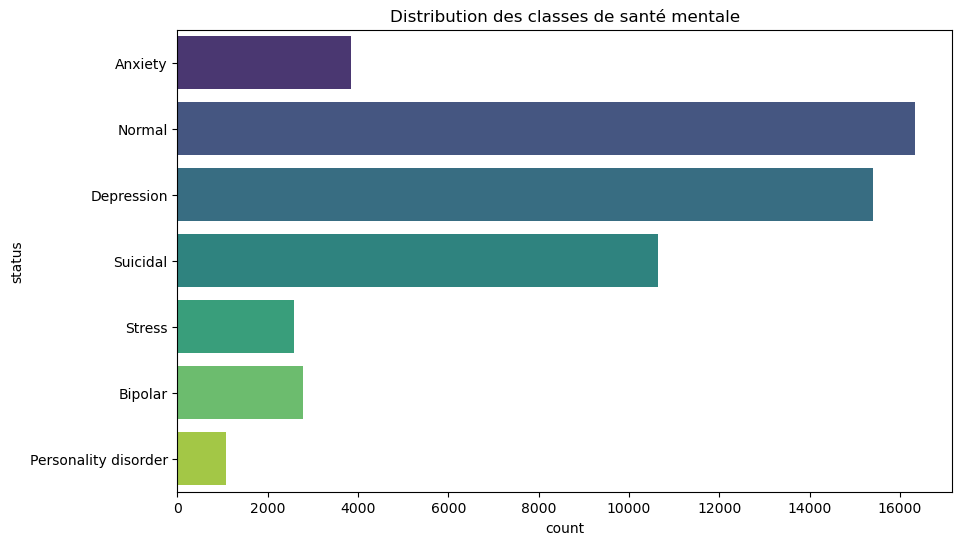

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.countplot(y='status', data=df, palette='viridis')
plt.title("Distribution des classes de santé mentale")
plt.show()

## 10. Longueur des textes

In [13]:
df['longueur_texte'] = df['statement'].astype(str).apply(lambda x: len(x.split()))
df['longueur_texte'].describe()

count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: longueur_texte, dtype: float64

## 11. Histogramme longueur

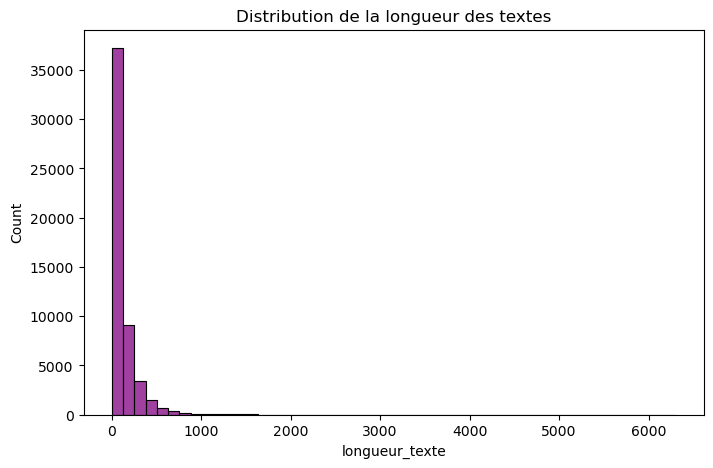

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['longueur_texte'], bins=50, color='purple')
plt.title("Distribution de la longueur des textes")
plt.show()

## 12.distrubution du longueur du text par rapport a la classe

Average word count per class:
 status
Normal                   17.246283
Stress                  114.585234
Anxiety                 143.837022
Suicidal                146.440293
Depression              168.021488
Bipolar                 176.200216
Personality disorder    179.346332
Name: word_count, dtype: float64


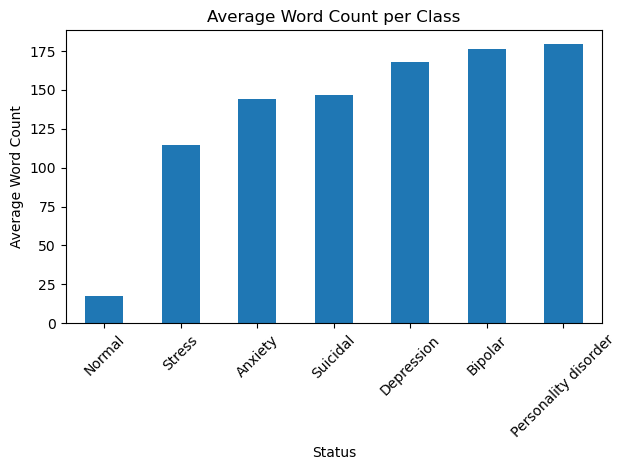

<Figure size 640x480 with 0 Axes>

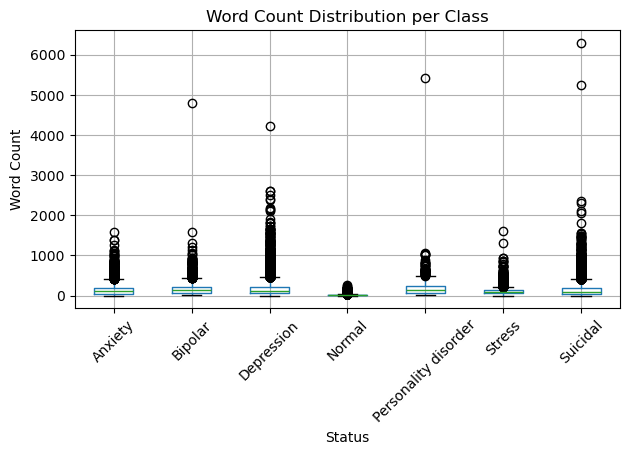

In [15]:

df['word_count'] = df['statement'].apply(lambda x: len(x.split()))



avg_word_count = df.groupby('status')['word_count'].mean().sort_values()

print("Average word count per class:\n", avg_word_count)



plt.figure()
avg_word_count.plot(kind='bar')

plt.title('Average Word Count per Class')
plt.xlabel('Status')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



plt.figure()
df.boxplot(column='word_count', by='status')

plt.title('Word Count Distribution per Class')
plt.suptitle('')  # remove default pandas title
plt.xlabel('Status')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Mots fréquents

In [16]:
from collections import Counter  

all_words = " ".join(df['statement'])
freq = Counter(all_words.split())
common_words = pd.DataFrame(freq.most_common(20), columns=['Mot','Fréquence'])
common_words

,Mot,Fréquence
0,I,319524
1,to,193910
2,and,169077
3,the,119388
4,a,115565
5,my,109073
6,of,83995
7,i,79599
8,not,72618
9,is,68692


## 14. Visualisation mots fréquents

/tmp/ipykernel_40566/1795140947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma')


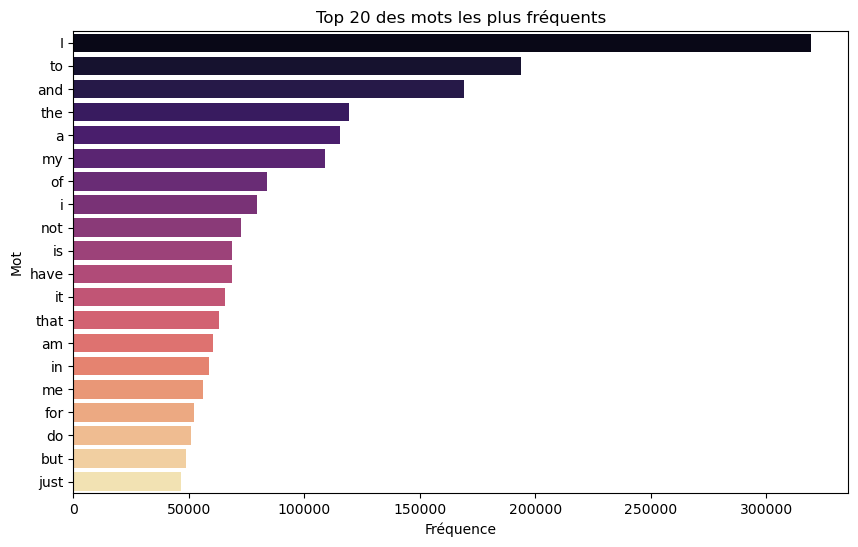

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='Fréquence', y='Mot', data=common_words, palette='magma')
plt.title("Top 20 des mots les plus fréquents")
plt.show()

## 16. Tableau final d’évaluation

In [18]:
evaluation = pd.DataFrame({
    'Critère':[
        'Taille dataset',
        'Qualité des données',
        'Labels structurés',
        'Compatibilité Machine Learning',
        'Compatibilité Deep Learning',
        'Pertinence projet santé mentale'
    ],
    'Évaluation':[
        'Très bonne',
        'Bonne',
        'Oui',
        'Excellente',
        'Très bonne',
        'Très élevée'
    ]
})
evaluation

,Critère,Évaluation
0,Taille dataset,Très bonne
1,Qualité des données,Bonne
2,Labels structurés,Oui
3,Compatibilité Machine Learning,Excellente
4,Compatibilité Deep Learning,Très bonne
5,Pertinence projet santé mentale,Très élevée


<h1 style="color:pink; text-decoration:underline">Partie 2 :Encodage des 7 classes</h1>

In [19]:
le = LabelEncoder()
df["status_encoded"] = le.fit_transform(df["status"])

# Voir le mapping complet
for i, classe in enumerate(le.classes_):
    print(f"{i} → {classe}")

y = df["status_encoded"]

0 → Anxiety
1 → Bipolar
2 → Depression
3 → Normal
4 → Personality disorder
5 → Stress
6 → Suicidal


<h1 style="color:pink; text-decoration:underline">Partie 3 :Prétraitement du Texte (NLP)</h1>

In [20]:
!pip install contractions
!pip install nltk

In [21]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mohamed/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:

# Imports
import re
import contractions

# Fonction de nettoyage
def clean_data(text):
    # 0. Convertir en string (évite les erreurs sur NaN)
    text = str(text)
    
    # 1. Normaliser les apostrophes
    text = text.replace("'", "'")
    
    # 2. Mettre en minuscules
    text = text.lower()
    
    # 3. Développer les contractions
    text = contractions.fix(text)
    
    # 4. Remplacer les mentions @
    text = re.sub(r'@\w+', ' <name> ', text)
    
    # 5. Remplacer les nombres
    text = re.sub(r'\d+', ' <number> ', text)
    
    # 6. Supprimer la ponctuation sauf ? et !
    text = re.sub(r"[^\w\s?!]", "", text)
    
    return text

# Appliquer sur le dataset
df["cleaned_statement"] = df["statement"].apply(clean_data)

# Vérifier le résultat
print(df[["statement", "cleaned_statement"]].head(5))

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                   cleaned_statement  
0                                         oh my gosh  
1  trouble sleeping confused mind restless heart ...  
2  all wrong back off dear forward doubt stay in ...  
3  i have shifted my focus to something else but ...  
4  i am restless and restless it is been a month ...  


In [23]:
df

,statement,status,longueur_texte,word_count,status_encoded,cleaned_statement
0,oh my gosh,Anxiety,3,3,0,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,10,0,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,14,0,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,11,11,0,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",Anxiety,14,14,0,i am restless and restless it is been a month ...
...,...,...,...,...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety,322,322,0,nobody takes me seriously i have number m dea...
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety,198,198,0,selfishness i do not feel very good it is lik...
53040,Is there any way to sleep better? I can't slee...,Anxiety,17,17,0,is there any way to sleep better? i cannot sle...
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety,74,74,0,public speaking tips? hi all i have to give a ...


<h1 style="color:pink; text-decoration:underline">Partie 4: tokenisation</h1>

In [24]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

from nltk.tokenize import word_tokenize

df['tokens'] = df['cleaned_statement'].apply(word_tokenize)

# Vérifier le résultat
print(df[['cleaned_statement', 'tokens']].head(3))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/mohamed/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/mohamed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                   cleaned_statement  \
0                                         oh my gosh   
1  trouble sleeping confused mind restless heart ...   
2  all wrong back off dear forward doubt stay in ...   

                                              tokens  
0                                     [oh, my, gosh]  
1  [trouble, sleeping, confused, mind, restless, ...  
2  [all, wrong, back, off, dear, forward, doubt, ...  


In [25]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 52681
Nombre de colonnes : 7


In [26]:
print(df.columns)

Index(['statement', 'status', 'longueur_texte', 'word_count', 'status_encoded',
       'cleaned_statement', 'tokens'],
      dtype='object')


<h1 style="color:pink; text-decoration:underline">Partie 5: Lemmatisation</h1>

In [27]:
import nltk
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

# Fonction 1 — convertir le POS tag
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'   # adjectif
    elif tag.startswith('V'):
        return 'v'   # verbe
    elif tag.startswith('N'):
        return 'n'   # nom
    elif tag.startswith('R'):
        return 'r'   # adverbe
    else:
        return 'n'   # défaut

def lemmatize_tokens(tokens):
    # ← vérifier que tokens est bien une liste
    if not isinstance(tokens, list):
        return []
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
# Appliquer sur le dataset
df['tokens'] = df['tokens'].apply(lemmatize_tokens)

# Reconstruire cleaned_statement depuis les tokens lemmatisés
df["cleaned_statement"] = df["tokens"].apply(lambda x: " ".join(x))

# Vérifier
print(df[['statement', 'cleaned_statement', 'tokens']].head(3))

[nltk_data] Downloading package punkt to /home/mohamed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mohamed/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/mohamed/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/mohamed/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   

                                   cleaned_statement  \
0                                         oh my gosh   
1  trouble sleep confuse mind restless heart all ...   
2  all wrong back off dear forward doubt stay in ...   

                                              tokens  
0                                     [oh, my, gosh]  
1  [trouble, sleep, confuse, mind, restless, hear...  
2  [all, wrong, back, off, dear, forward, doubt, ...  


<h1 style="color:pink; text-decoration:underline">Partie 6: Vectorisation TF-IDF</h1>

In [28]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [29]:
print("Colonnes disponibles :", df.columns.tolist())
print("Shape :", df.shape)
print(df.head(2))

Colonnes disponibles : ['statement', 'status', 'longueur_texte', 'word_count', 'status_encoded', 'cleaned_statement', 'tokens']
Shape : (52681, 7)
                                           statement   status  longueur_texte  \
0                                         oh my gosh  Anxiety               3   
1  trouble sleeping, confused mind, restless hear...  Anxiety              10   

   word_count  status_encoded  \
0           3               0   
1          10               0   

                                   cleaned_statement  \
0                                         oh my gosh   
1  trouble sleep confuse mind restless heart all ...   

                                              tokens  
0                                     [oh, my, gosh]  
1  [trouble, sleep, confuse, mind, restless, hear...  


In [30]:
from gensim.models import Word2Vec
import numpy as np

# Entraîner Word2Vec
w2v_model = Word2Vec(
    df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Mean pooling — convertir chaque phrase en vecteur
def sentence_vector(tokens):
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_w2v = np.array([sentence_vector(t) for t in df['tokens']])
y = df['status_encoded']

print("Shape X Word2Vec :", X_w2v.shape)
# → (52681, 100)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Shape X Word2Vec : (52681, 100)


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df['cleaned_statement'])

print("Shape X TF-IDF :", X_tfidf.shape)
# → (52681, 10000)

Shape X TF-IDF : (52681, 10000)


<h1 style="color:pink; text-decoration:underline">Partie 7: SMOTE pour les deux</h1>

In [32]:
from imblearn.over_sampling import SMOTE
import collections

# SMOTE Word2Vec
smote = SMOTE(random_state=42)
X_w2v_res, y_w2v_res = smote.fit_resample(X_w2v, y)
print("Après SMOTE Word2Vec :", collections.Counter(y_w2v_res))

# SMOTE TF-IDF
X_tfidf_res, y_tfidf_res = smote.fit_resample(X_tfidf, y)
print("Après SMOTE TF-IDF  :", collections.Counter(y_tfidf_res))

Après SMOTE Word2Vec : Counter({0: 16343, 3: 16343, 2: 16343, 6: 16343, 5: 16343, 1: 16343, 4: 16343})
Après SMOTE TF-IDF  : Counter({0: 16343, 3: 16343, 2: 16343, 6: 16343, 5: 16343, 1: 16343, 4: 16343})


<h1 style="color:pink; text-decoration:underline">Partie 8: Train/Test Split pour les deux</h1>

In [33]:
from sklearn.model_selection import train_test_split

# Split Word2Vec
X_w2v_train, X_w2v_test, y_w2v_train, y_w2v_test = train_test_split(
    X_w2v_res, y_w2v_res,
    test_size=0.3,
    random_state=42,
    stratify=y_w2v_res
)

# Split TF-IDF
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(
    X_tfidf_res, y_tfidf_res,
    test_size=0.3,
    random_state=42,
    stratify=y_tfidf_res
)

print("Word2Vec → Train:", X_w2v_train.shape, "Test:", X_w2v_test.shape)
print("TF-IDF   → Train:", X_tfidf_train.shape, "Test:", X_tfidf_test.shape)

Word2Vec → Train: (80080, 100) Test: (34321, 100)
TF-IDF   → Train: (80080, 10000) Test: (34321, 10000)


<h1 style="color:pink; text-decoration:underline">Partie 9: SVM sur Word2Vec</h1>

In [34]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_w2v = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000)
svm_w2v.fit(X_w2v_train, y_w2v_train)

y_pred_w2v = svm_w2v.predict(X_w2v_test)

print("=" * 50)
print("RÉSULTATS SVM + Word2Vec")
print("=" * 50)
print(classification_report(
    y_w2v_test, y_pred_w2v,
    target_names=le.classes_
))

RÉSULTATS SVM + Word2Vec
                      precision    recall  f1-score   support

             Anxiety       0.71      0.74      0.73      4903
             Bipolar       0.68      0.70      0.69      4903
          Depression       0.57      0.25      0.35      4903
              Normal       0.69      0.69      0.69      4903
Personality disorder       0.58      0.73      0.65      4903
              Stress       0.58      0.61      0.59      4903
            Suicidal       0.60      0.70      0.65      4903

            accuracy                           0.63     34321
           macro avg       0.63      0.63      0.62     34321
        weighted avg       0.63      0.63      0.62     34321



<h1 style="color:pink; text-decoration:underline">Partie 10: SVM  sur TF-IDF</h1>

In [35]:
svm_tfidf = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000)
svm_tfidf.fit(X_tfidf_train, y_tfidf_train)

y_pred_tfidf = svm_tfidf.predict(X_tfidf_test)

print("=" * 50)
print("RÉSULTATS SVM + TF-IDF")
print("=" * 50)
print(classification_report(
    y_tfidf_test, y_pred_tfidf,
    target_names=le.classes_
))

RÉSULTATS SVM + TF-IDF
                      precision    recall  f1-score   support

             Anxiety       0.93      0.94      0.93      4903
             Bipolar       0.96      0.98      0.97      4903
          Depression       0.76      0.63      0.69      4903
              Normal       0.82      0.85      0.84      4903
Personality disorder       0.97      1.00      0.99      4903
              Stress       0.89      0.94      0.91      4903
            Suicidal       0.74      0.74      0.74      4903

            accuracy                           0.87     34321
           macro avg       0.87      0.87      0.87     34321
        weighted avg       0.87      0.87      0.87     34321



<h1 style="color:pink; text-decoration:underline">Partie 11: Comparaison finale</h1>

In [36]:
from sklearn.metrics import accuracy_score, f1_score

acc_w2v   = accuracy_score(y_w2v_test, y_pred_w2v)
acc_tfidf = accuracy_score(y_tfidf_test, y_pred_tfidf)

f1_w2v   = f1_score(y_w2v_test, y_pred_w2v, average='macro')
f1_tfidf = f1_score(y_tfidf_test, y_pred_tfidf, average='macro')

print("╔══════════════════════════════════════╗")
print("║       COMPARAISON FINALE             ║")
print("╠══════════════════════════════════════╣")
print(f"║ Word2Vec │ Accuracy: {acc_w2v:.2%}  F1: {f1_w2v:.2%} ║")
print(f"║ TF-IDF   │ Accuracy: {acc_tfidf:.2%}  F1: {f1_tfidf:.2%} ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║       COMPARAISON FINALE             ║
╠══════════════════════════════════════╣
║ Word2Vec │ Accuracy: 63.22%  F1: 62.04% ║
║ TF-IDF   │ Accuracy: 87.02%  F1: 86.76% ║
╚══════════════════════════════════════╝


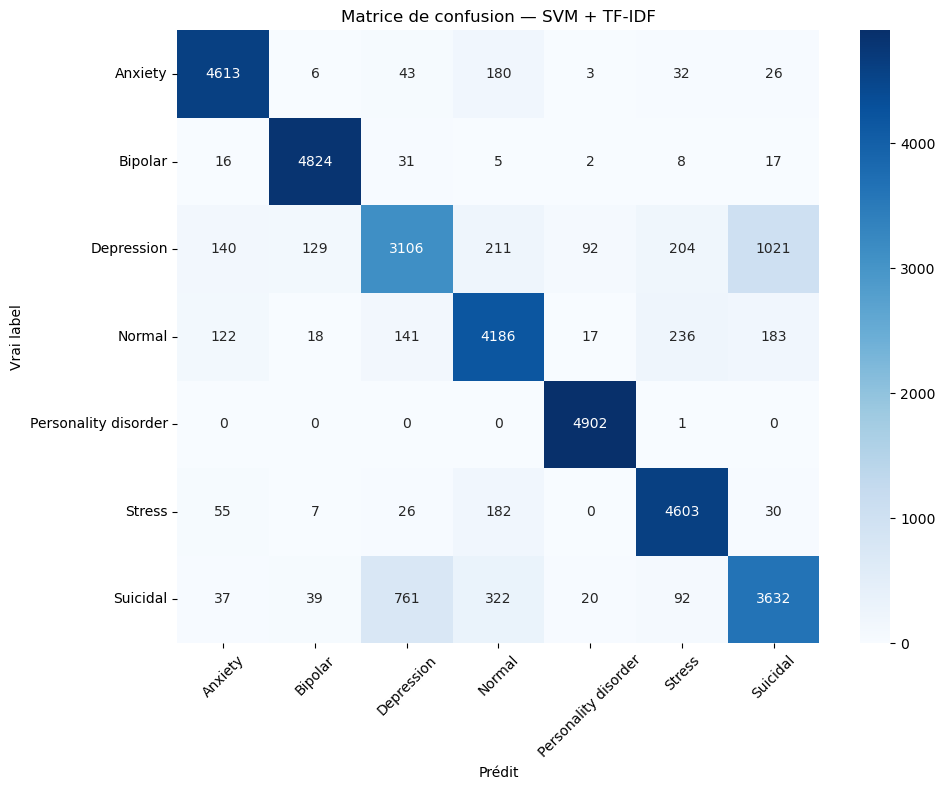

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_tfidf_test, y_pred_tfidf)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matrice de confusion — SVM + TF-IDF')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

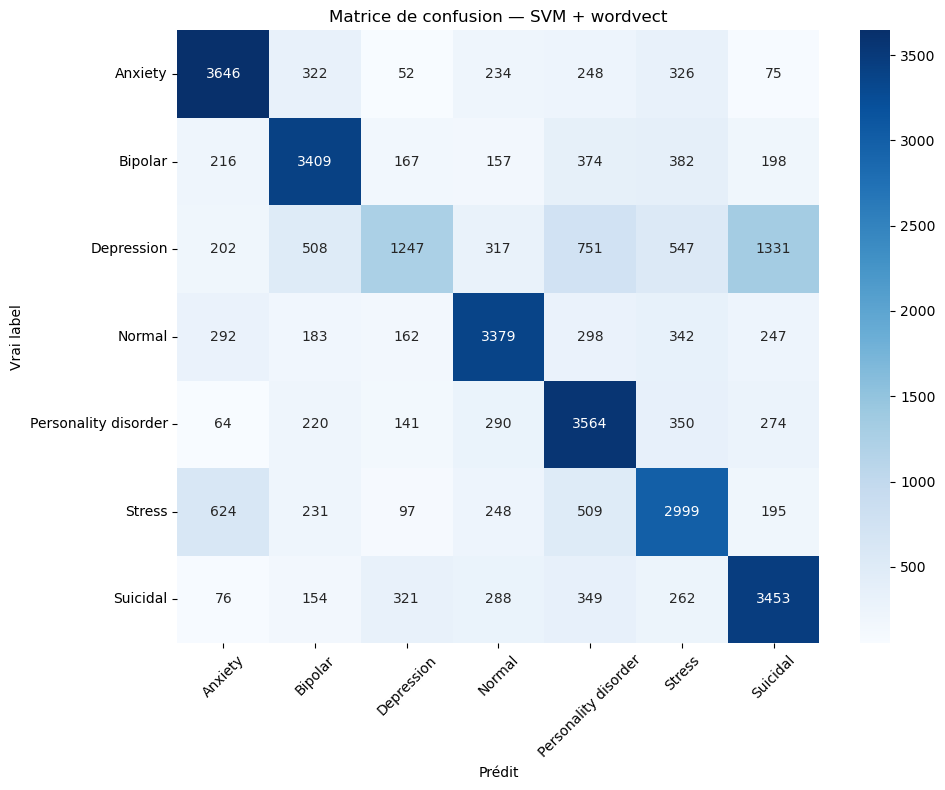

In [38]:
cm = confusion_matrix(y_w2v_test, y_pred_w2v)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matrice de confusion — SVM + wordvect')
plt.ylabel('Vrai label')







plt.xlabel('Prédit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Définir les 4 combinaisons
modeles = {
    'TF-IDF + LR' : {
        'X_train': X_tfidf_train,
        'X_test' : X_tfidf_test,
        'y_train': y_tfidf_train,
        'y_test' : y_tfidf_test,
        'model'  : LogisticRegression(
                       class_weight='balanced',
                       max_iter=1000,
                       random_state=42
                   )
    },
    'TF-IDF + SVM' : {
        'X_train': X_tfidf_train,
        'X_test' : X_tfidf_test,
        'y_train': y_tfidf_train,
        'y_test' : y_tfidf_test,
        'model'  : LinearSVC(
                       class_weight='balanced',
                       max_iter=1000,
                       random_state=42
                   )
    },
    'Word2Vec + LR' : {
        'X_train': X_w2v_train,
        'X_test' : X_w2v_test,
        'y_train': y_w2v_train,
        'y_test' : y_w2v_test,
        'model'  : LogisticRegression(
                       class_weight='balanced',
                       max_iter=1000,
                       random_state=42
                   )
    },
    'Word2Vec + SVM' : {
        'X_train': X_w2v_train,
        'X_test' : X_w2v_test,
        'y_train': y_w2v_train,
        'y_test' : y_w2v_test,
        'model'  : LinearSVC(
                       class_weight='balanced',
                       max_iter=1000,
                       random_state=42
                   )
    }
}

In [40]:
resultats = []

for nom, config in modeles.items():
    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    
    # Entraînement
    config['model'].fit(config['X_train'], config['y_train'])
    
    # Prédiction
    y_pred = config['model'].predict(config['X_test'])
    
    # Métriques
    acc = accuracy_score(config['y_test'], y_pred)
    f1  = f1_score(config['y_test'], y_pred, average='macro')
    
    # Rapport détaillé
    print(classification_report(
        config['y_test'], y_pred,
        target_names=le.classes_
    ))
    
    # Sauvegarder résultats
    resultats.append({
        'Modèle'  : nom,
        'Accuracy': round(acc * 100, 2),
        'F1 Macro': round(f1, 4)
    })


  TF-IDF + LR
                      precision    recall  f1-score   support

             Anxiety       0.90      0.87      0.89      4903
             Bipolar       0.95      0.95      0.95      4903
          Depression       0.74      0.63      0.68      4903
              Normal       0.75      0.87      0.81      4903
Personality disorder       0.95      0.99      0.97      4903
              Stress       0.86      0.87      0.87      4903
            Suicidal       0.73      0.71      0.72      4903

            accuracy                           0.84     34321
           macro avg       0.84      0.84      0.84     34321
        weighted avg       0.84      0.84      0.84     34321


  TF-IDF + SVM
                      precision    recall  f1-score   support

             Anxiety       0.93      0.94      0.93      4903
             Bipolar       0.96      0.98      0.97      4903
          Depression       0.76      0.63      0.69      4903
              Normal       0.82    

In [41]:
import pandas as pd

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('F1 Macro', ascending=False)
df_resultats = df_resultats.reset_index(drop=True)

print("\n╔══════════════════════════════════════════╗")
print("║         COMPARAISON FINALE               ║")
print("╠══════════════════════════════════════════╣")
for _, row in df_resultats.iterrows():
    print(f"║ {row['Modèle']:<18} │ Acc: {row['Accuracy']}%  F1: {row['F1 Macro']} ║")
print("╚══════════════════════════════════════════╝")


╔══════════════════════════════════════════╗
║         COMPARAISON FINALE               ║
╠══════════════════════════════════════════╣
║ TF-IDF + SVM       │ Acc: 87.02%  F1: 0.8676 ║
║ TF-IDF + LR        │ Acc: 84.17%  F1: 0.8398 ║
║ Word2Vec + LR      │ Acc: 63.52%  F1: 0.6325 ║
║ Word2Vec + SVM     │ Acc: 63.22%  F1: 0.6204 ║
╚══════════════════════════════════════════╝


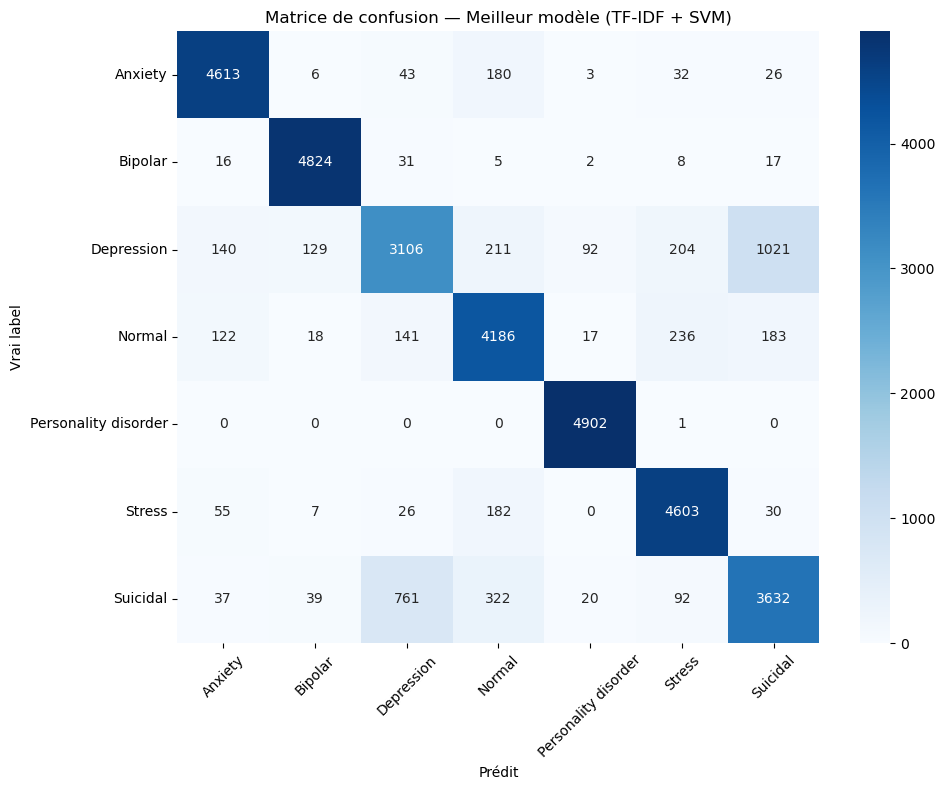

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Meilleur modèle = TF-IDF + SVM
best_model = modeles['TF-IDF + SVM']['model']
y_pred_best = best_model.predict(X_tfidf_test)

cm = confusion_matrix(y_tfidf_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matrice de confusion — Meilleur modèle (TF-IDF + SVM)')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1 style="color:pink; text-decoration:underline">Partie 12: TF-IDF + LR avec GridSearch</h1> 

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("="*50)
print("  TF-IDF + LR — Optimisation")
print("="*50)

param_lr = {
    'C'      : [0.01, 0.1, 1, 10],
    'solver' : ['liblinear', 'saga'],
    'max_iter': [500, 1000]
}

lr_tfidf = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_tfidf.fit(X_tfidf_train, y_tfidf_train)

print("Meilleurs paramètres :", lr_tfidf.best_params_)
print("Meilleur F1 macro    :", round(lr_tfidf.best_score_, 4))

  TF-IDF + LR — Optimisation
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/mohamed/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/mohamed/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/mohamed/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another s

KeyboardInterrupt: 

<h1 style="color:pink; text-decoration:underline">Partie 13: TF-IDF + SVM avec GridSearch</h1> 

In [ ]:
from sklearn.svm import LinearSVC

print("="*50)
print("  TF-IDF + SVM — Optimisation")
print("="*50)

param_svm = {
    'C'       : [0.01, 0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

svm_tfidf = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42),
    param_grid=param_svm,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

svm_tfidf.fit(X_tfidf_train, y_tfidf_train)

print("Meilleurs paramètres :", svm_tfidf.best_params_)
print("Meilleur F1 macro    :", round(svm_tfidf.best_score_, 4))


In [ ]:
print("="*50)
print("  Word2Vec + LR — Optimisation")
print("="*50)

lr_w2v = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_w2v.fit(X_w2v_train, y_w2v_train)

print("Meilleurs paramètres :", lr_w2v.best_params_)
print("Meilleur F1 macro    :", round(lr_w2v.best_score_, 4))

In [ ]:
print("="*50)
print("  Word2Vec + SVM — Optimisation")
print("="*50)

svm_w2v = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42),
    param_grid=param_svm,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

svm_w2v.fit(X_w2v_train, y_w2v_train)

print("Meilleurs paramètres :", svm_w2v.best_params_)
print("Meilleur F1 macro    :", round(svm_w2v.best_score_, 4))

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

modeles_optimises = {
    'TF-IDF + LR' : {
        'model' : lr_tfidf,
        'X_test': X_tfidf_test,
        'y_test': y_tfidf_test
    },
    'TF-IDF + SVM' : {
        'model' : svm_tfidf,
        'X_test': X_tfidf_test,
        'y_test': y_tfidf_test
    },
    'Word2Vec + LR' : {
        'model' : lr_w2v,
        'X_test': X_w2v_test,
        'y_test': y_w2v_test
    },
    'Word2Vec + SVM' : {
        'model' : svm_w2v,
        'X_test': X_w2v_test,
        'y_test': y_w2v_test
    }
}

resultats = []

for nom, config in modeles_optimises.items():
    y_pred = config['model'].predict(config['X_test'])
    acc    = accuracy_score(config['y_test'], y_pred)
    f1     = f1_score(config['y_test'], y_pred, average='macro')

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(classification_report(
        config['y_test'], y_pred,
        target_names=le.classes_
    ))

    resultats.append({
        'Modèle'        : nom,
        'Accuracy'      : round(acc * 100, 2),
        'F1 Macro'      : round(f1, 4),
        'Best Params'   : config['model'].best_params_
    })

In [ ]:
import pandas as pd

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('F1 Macro', ascending=False)
df_resultats = df_resultats.reset_index(drop=True)

print("\n╔══════════════════════════════════════════════════╗")
print("║         COMPARAISON FINALE OPTIMISÉE             ║")
print("╠══════════════════════════════════════════════════╣")
for _, row in df_resultats.iterrows():
    print(f"║ {row['Modèle']:<18} │ Acc: {row['Accuracy']}%  F1: {row['F1 Macro']} ║")
print("╚══════════════════════════════════════════════════╝")

print("\nMeilleurs paramètres :")
for _, row in df_resultats.iterrows():
    print(f"  {row['Modèle']:<18} → {row['Best Params']}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Identifier le meilleur modèle automatiquement
meilleur = df_resultats.iloc[0]['Modèle']
config   = modeles_optimises[meilleur]

y_pred_best = config['model'].predict(config['X_test'])
cm = confusion_matrix(config['y_test'], y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title(f'Matrice de confusion — {meilleur} (optimisé)')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                      Données

                          ↓

TF-IDF                                 Word2Vec
   ↓                                       ↓

LR + GridSearch                     LR + GridSearch

SVM + GridSearch                     SVM + GridSearch
   ↓                                        ↓
   
                 4 modèles optimisés
                           ↓
   
                   Tableau comparatif
                              ↓
                 
                 Meilleur modèle → Matrice confusion